
# BCI Competition IV-2a — Robust EA + EEGNet + Binary DANN LOSO

This notebook is a clean, executable cross-subject motor-imagery pipeline for
**BCI Competition IV dataset 2a**.

## Default experiment

The notebook starts with:

**4–38 Hz → 22 EEG channels → 4 s `[2.0, 6.0)` epochs → subject-wise Euclidean Alignment → EEGNet → 4-class classification**

and uses **transductive target EA** by default:

- target EEG is used *without labels* to estimate its EA covariance;
- target labels are used only for final evaluation;
- target EEG is not used for the baseline classifier training.

This avoids the source/target preprocessing mismatch in the previous notebook.

## DANN experiment

A second mode adds a **binary source-vs-target domain discriminator** with a Gradient Reversal Layer:

```text
                        ┌── 4-class task classifier
                        │
EEGNet feature ─────────┤
                        │
                        └── GRL → binary domain classifier
                                      Source / Target
```

The DANN loss is:

\[
L = L_{task} + \lambda(p)L_{domain}
\]

with the standard logistic DANN schedule and a conservative `LAMBDA_MAX=0.3`.

## Important protocol note

The default `EA_TARGET_MODE="transductive"` is an **unsupervised domain-adaptation** protocol, not a completely inaccessible unseen-user test. No target motor-imagery labels are used during preprocessing or training.

For strict inductive LOSO, set:

```python
CFG.EA_TARGET_MODE = "identity"
```

The notebook is deliberately configured to run the **EA + EEGNet baseline first** before the DANN experiment.



## 0. Environment

The uploaded notebook was running under approximately:

- Python 3.10
- PyTorch 2.10.0
- MNE 1.11.x
- Apple MPS

The previous installation cell failed because it attempted to force `braindecode==1.7.0`, which is not available for the Python 3.10 environment shown in the notebook.

This version therefore **does not require Braindecode**. EEGNet is implemented directly in PyTorch and preprocessing is done with MNE. Braindecode can be added later as an independent comparison.

The installation cell below checks the environment and installs only missing scientific Python packages; it does not force a PyTorch downgrade.


In [1]:

# CELL 1 — SAFE ENVIRONMENT CHECK
# Does not force a PyTorch downgrade and does not require Braindecode.

import sys
import subprocess
import importlib.util

print("Python:", sys.version)

required_imports = {
    "numpy": "numpy",
    "scipy": "scipy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "mne": "mne",
    "torch": "torch",
    "tqdm": "tqdm",
}

missing = [
    pip_name
    for module_name, pip_name in required_imports.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-U", *missing]
    )
else:
    print("All required packages are already installed.")

# Braindecode is OPTIONAL for this notebook.
print("Braindecode dependency: optional; EEGNet is implemented directly in PyTorch.")


Python: 3.10.19 (main, Oct 21 2025, 16:37:10) [Clang 20.1.8 ]
All required packages are already installed.
Braindecode dependency: optional; EEGNet is implemented directly in PyTorch.


In [2]:

# CELL 2 — IMPORTS, REPRODUCIBILITY, DEVICE

import os
import re
import json
import math
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)

from tqdm.auto import tqdm

print("MNE:", mne.__version__)
print("PyTorch:", torch.__version__)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)

# MPS is useful on Apple Silicon.
if DEVICE.type == "mps":
    print("Apple MPS detected.")


MNE: 1.11.0
PyTorch: 2.10.0
DEVICE: mps
Apple MPS detected.


In [3]:

# CELL 3 — CONFIGURATION

@dataclass
class Config:

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    DATA_ROOT: str = "./BCICIV_2a"

    SUBJECTS: Tuple[str, ...] = tuple(
        f"A{i:02d}" for i in range(1, 10)
    )

    # --------------------------------------------------------
    # EEG preprocessing
    # --------------------------------------------------------

    N_CHANNELS: int = 22

    SFREQ: float = 250.0

    L_FREQ: float = 4.0

    H_FREQ: float = 38.0

    TMIN: float = 2.0

    TMAX: float = 6.0

    # Event codes in BCI IV-2a
    EVENT_CODES: Dict[int, int] = None

    # --------------------------------------------------------
    # Euclidean Alignment
    # --------------------------------------------------------

    EA_EPS: float = 1e-6

    # "transductive":
    #   estimate target EA from unlabeled target EEG.
    #
    # "identity":
    #   target is NOT EA transformed.
    #
    # Default is transductive because source-only EA with
    # raw target creates a preprocessing distribution mismatch.
    EA_TARGET_MODE: str = "transductive"

    # --------------------------------------------------------
    # EEGNet
    # --------------------------------------------------------

    EEGNET_F1: int = 8

    EEGNET_D: int = 2

    EEGNET_F2: int = 16

    # Odd kernel avoids even-kernel "same" padding ambiguity.
    EEGNET_KERNEL_LENGTH: int = 63

    EEGNET_DROPOUT: float = 0.5

    EEGNET_MAX_NORM: float = 1.0

    # --------------------------------------------------------
    # DANN
    # --------------------------------------------------------

    # Binary domain classifier:
    #   0 = source
    #   1 = target
    DOMAIN_HIDDEN_1: int = 64
    DOMAIN_HIDDEN_2: int = 32
    DOMAIN_DROPOUT: float = 0.3

    # Conservative maximum adversarial weight.
    LAMBDA_MAX: float = 0.30

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    EPOCHS: int = 80

    BATCH_SIZE: int = 64

    # For binary DANN, half-source + half-target per step.
    DOMAIN_BATCH_SIZE: int = 32

    LR: float = 1e-3

    WEIGHT_DECAY: float = 1e-4

    ETA_MIN: float = 1e-5

    GRAD_CLIP_NORM: float = 5.0

    NUM_WORKERS: int = 0

    # --------------------------------------------------------
    # Experiment control
    # --------------------------------------------------------

    # "baseline_raw"
    # "baseline_ea"
    # "dann_binary"
    RUN_MODE: str = "baseline_ea"

    # Start with A01 only.
    # Set None for all nine LOSO folds.
    MAX_FOLDS: Optional[int] = 1

    # --------------------------------------------------------
    # Outputs
    # --------------------------------------------------------

    OUTPUT_ROOT: str = "./outputs_bci_iv2a"


CFG = Config()

CFG.EVENT_CODES = {
    769: 0,  # Left hand
    770: 1,  # Right hand
    771: 2,  # Both feet
    772: 3,  # Tongue
}

EXPECTED_SAMPLES = int(
    round(
        (CFG.TMAX - CFG.TMIN)
        * CFG.SFREQ
    )
)

CFG_TMAX = CFG.TMAX - 1.0 / CFG.SFREQ

Path(CFG.OUTPUT_ROOT).mkdir(
    parents=True,
    exist_ok=True,
)

print("=" * 72)
print("CONFIGURATION")
print("=" * 72)

print("DATA_ROOT:", CFG.DATA_ROOT)
print("RUN_MODE:", CFG.RUN_MODE)
print("EA_TARGET_MODE:", CFG.EA_TARGET_MODE)
print("Channels:", CFG.N_CHANNELS)
print("Sampling frequency:", CFG.SFREQ)
print(f"Bandpass: {CFG.L_FREQ}-{CFG.H_FREQ} Hz")
print(f"Epoch: [{CFG.TMIN}, {CFG.TMAX}) seconds")
print("Expected samples:", EXPECTED_SAMPLES)
print("Epochs:", CFG.EPOCHS)
print("Batch size:", CFG.BATCH_SIZE)
print("Learning rate:", CFG.LR)
print("Lambda max:", CFG.LAMBDA_MAX)
print("MAX_FOLDS:", CFG.MAX_FOLDS)
print("=" * 72)


CONFIGURATION
DATA_ROOT: ./BCICIV_2a
RUN_MODE: baseline_ea
EA_TARGET_MODE: transductive
Channels: 22
Sampling frequency: 250.0
Bandpass: 4.0-38.0 Hz
Epoch: [2.0, 6.0) seconds
Expected samples: 1000
Epochs: 80
Batch size: 64
Learning rate: 0.001
Lambda max: 0.3
MAX_FOLDS: 1


In [4]:

# CELL 4 — DATASET FILE DISCOVERY

DATA_ROOT = Path(CFG.DATA_ROOT)

def find_subject_file(
    subject_id: str,
    root: Path = DATA_ROOT,
) -> Path:

    patterns = [
        f"{subject_id}T.gdf",
        f"{subject_id.lower()}T.gdf",
    ]

    for pattern in patterns:
        matches = list(root.rglob(pattern))
        if matches:
            return matches[0]

    raise FileNotFoundError(
        f"Could not find {subject_id}T.gdf under "
        f"{root.resolve()}"
    )


for sid in CFG.SUBJECTS:
    print(
        sid,
        "->",
        find_subject_file(sid),
    )


A01 -> BCICIV_2a/A01T.gdf
A02 -> BCICIV_2a/A02T.gdf
A03 -> BCICIV_2a/A03T.gdf
A04 -> BCICIV_2a/A04T.gdf
A05 -> BCICIV_2a/A05T.gdf
A06 -> BCICIV_2a/A06T.gdf
A07 -> BCICIV_2a/A07T.gdf
A08 -> BCICIV_2a/A08T.gdf
A09 -> BCICIV_2a/A09T.gdf


In [5]:

# CELL 5 — INSPECT THE RAW GDF STRUCTURE

TEST_SUBJECT = CFG.SUBJECTS[0]

raw_inspect = mne.io.read_raw_gdf(
    find_subject_file(TEST_SUBJECT),
    preload=False,
    verbose="ERROR",
)

print(raw_inspect)

print("\nSampling frequency:")
print(raw_inspect.info["sfreq"])

print("\nChannels:")
for idx, ch in enumerate(raw_inspect.ch_names):
    print(f"{idx:02d}: {ch}")

print("\nAnnotations:")
print(raw_inspect.annotations)

events_preview, event_id_preview = mne.events_from_annotations(
    raw_inspect,
    verbose="ERROR",
)

print("\nMNE annotation mapping:")
print(event_id_preview)

print("\nUnique event IDs:")
print(np.unique(events_preview[:, 2]))


<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~29 KiB, data not loaded>

Sampling frequency:
250.0

Channels:
00: EEG-Fz
01: EEG-0
02: EEG-1
03: EEG-2
04: EEG-3
05: EEG-4
06: EEG-5
07: EEG-C3
08: EEG-6
09: EEG-Cz
10: EEG-7
11: EEG-C4
12: EEG-8
13: EEG-9
14: EEG-10
15: EEG-11
16: EEG-12
17: EEG-13
18: EEG-14
19: EEG-Pz
20: EEG-15
21: EEG-16
22: EOG-left
23: EOG-central
24: EOG-right

Annotations:
<Annotations | 603 segments: 1023 (15), 1072 (1), 276 (1), 277 (1), 32766 ...>

MNE annotation mapping:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}

Unique event IDs:
[ 1  2  3  4  5  6  7  8  9 10]


In [6]:

# CELL 6 — ROBUST BCI IV-2a EVENT EXTRACTION

def numeric_annotation_events(
    raw: mne.io.BaseRaw,
) -> np.ndarray:

    """
    Convert numeric annotation descriptions such as
    '769' into an MNE event array.

    Returns:
        (n_events, 3)
    """

    sfreq = float(
        raw.info["sfreq"]
    )

    rows = []

    for onset, desc in zip(
        raw.annotations.onset,
        raw.annotations.description,
    ):

        desc_str = str(desc).strip()

        # Exact numeric description is preferred.
        try:
            value = float(desc_str)
        except ValueError:
            match = re.search(
                r"\d+(?:\.\d+)?",
                desc_str,
            )

            if match is None:
                continue

            value = float(
                match.group(0)
            )

        if not value.is_integer():
            continue

        code = int(value)

        sample = int(
            round(
                float(onset) * sfreq
            )
        )

        rows.append(
            [sample, 0, code]
        )

    if not rows:
        raise RuntimeError(
            "No numeric annotations were found."
        )

    return np.asarray(
        rows,
        dtype=np.int64,
    )


def extract_mi_events(
    raw: mne.io.BaseRaw,
) -> np.ndarray:

    events = numeric_annotation_events(
        raw
    )

    valid_codes = np.asarray(
        list(CFG.EVENT_CODES.keys()),
        dtype=np.int64,
    )

    keep = np.isin(
        events[:, 2],
        valid_codes,
    )

    mi_events = events[keep]

    if len(mi_events) == 0:
        raise RuntimeError(
            "No motor-imagery events 769-772 were found."
        )

    return mi_events


def print_event_summary(
    events: np.ndarray,
):

    counts = {
        int(code): int(
            np.sum(
                events[:, 2] == code
            )
        )
        for code in CFG.EVENT_CODES
    }

    print("MI event counts:", counts)
    print("Total MI events:", len(events))


In [7]:
# ============================================================
# CELL 7 — FINAL LOAD / FILTER / EPOCH FUNCTION
# ============================================================
#
# BCI Competition IV-2a
#
# Processing:
#   1. Load GDF
#   2. Keep 22 EEG channels
#   3. Exclude 3 EOG channels
#   4. Bandpass 4–38 Hz
#   5. Extract MI events 769–772
#   6. Epoch [2.0, 6.0) relative to cue
#
# NOTE:
# The final trial in some GDF recordings can occur too close
# to the recording boundary to provide the complete 4-second
# epoch. MNE reports this as TOO_SHORT.
#
# We DO NOT zero-pad the final trial.
# We keep only physically available complete epochs.
# ============================================================

EOG_CHANNELS = {
    "EOG-left",
    "EOG-central",
    "EOG-right",
}

CLASS_NAMES = [
    "Left hand",
    "Right hand",
    "Both feet",
    "Tongue",
]


def load_subject_epochs(
    subject_id: str,
) -> Tuple[np.ndarray, np.ndarray]:

    print("\n" + "=" * 80)
    print(f"LOADING SUBJECT {subject_id}")
    print("=" * 80)

    # --------------------------------------------------------
    # 1. Locate file
    # --------------------------------------------------------

    path = find_subject_file(
        subject_id
    )

    print("File:", path)


    # --------------------------------------------------------
    # 2. Load GDF
    # --------------------------------------------------------

    raw = mne.io.read_raw_gdf(
        path,
        preload=True,
        verbose="ERROR",
    )

    print(
        "Original channels:",
        len(raw.ch_names),
    )


    # --------------------------------------------------------
    # 3. Explicitly select 22 EEG channels
    # --------------------------------------------------------

    eeg_channels = [
        ch
        for ch in raw.ch_names
        if ch not in EOG_CHANNELS
    ]


    if len(eeg_channels) != CFG.N_CHANNELS:

        raise ValueError(

            f"{subject_id}: expected "
            f"{CFG.N_CHANNELS} EEG channels, "
            f"found {len(eeg_channels)}.\n\n"

            f"Selected channels:\n"
            f"{eeg_channels}\n\n"

            f"Original channels:\n"
            f"{raw.ch_names}"
        )


    raw.pick(
        eeg_channels
    )


    print(
        "EEG channels:",
        len(raw.ch_names),
    )


    # --------------------------------------------------------
    # 4. Verify sampling frequency
    # --------------------------------------------------------

    sfreq = float(
        raw.info["sfreq"]
    )


    if not np.isclose(
        sfreq,
        CFG.SFREQ,
    ):

        raise ValueError(

            f"{subject_id}: expected "
            f"{CFG.SFREQ} Hz but found "
            f"{sfreq} Hz."
        )


    print(
        "Sampling frequency:",
        sfreq,
    )


    # --------------------------------------------------------
    # 5. Bandpass filter
    # --------------------------------------------------------

    print(
        f"Applying "
        f"{CFG.L_FREQ}–{CFG.H_FREQ} Hz "
        f"bandpass..."
    )


    raw.filter(
        l_freq=CFG.L_FREQ,
        h_freq=CFG.H_FREQ,
        method="fir",
        phase="zero",
        verbose="ERROR",
    )


    # --------------------------------------------------------
    # 6. Extract MI events
    # --------------------------------------------------------

    mi_events = extract_mi_events(
        raw
    )


    print(
        "\nMI events found:",
        len(mi_events),
    )


    print_event_summary(
        mi_events
    )


    # --------------------------------------------------------
    # 7. Event mapping
    # --------------------------------------------------------

    event_id = {

        "Left hand": 769,

        "Right hand": 770,

        "Both feet": 771,

        "Tongue": 772,
    }


    # --------------------------------------------------------
    # 8. Epoch
    #
    # CFG_TMAX = 5.996 s gives exactly
    # 1000 samples at 250 Hz.
    # --------------------------------------------------------

    epochs = mne.Epochs(

        raw,

        mi_events,

        event_id=event_id,

        tmin=CFG.TMIN,

        tmax=CFG_TMAX,

        baseline=None,

        preload=True,

        # Important:
        # annotations do NOT cause epoch rejection.
        reject_by_annotation=False,

        verbose="ERROR",
    )


    # --------------------------------------------------------
    # 9. Report boundary-dropped trials
    # --------------------------------------------------------

    dropped_events = []

    for idx, reason in enumerate(
        epochs.drop_log
    ):

        if len(reason) > 0:

            dropped_events.append(
                (
                    idx,
                    reason,
                )
            )


    if dropped_events:

        print(
            "\nBoundary / epoch drops:"
        )

        for idx, reason in dropped_events:

            sample = int(
                mi_events[idx, 0]
            )

            code = int(
                mi_events[idx, 2]
            )

            time_sec = (
                sample / sfreq
            )

            print(

                f"  event={idx:03d} | "

                f"time={time_sec:.3f}s | "

                f"code={code} | "

                f"reason={reason}"
            )

    else:

        print(
            "\nNo epochs were dropped."
        )


    # --------------------------------------------------------
    # 10. Extract data
    # --------------------------------------------------------

    X = epochs.get_data(
        copy=True
    ).astype(
        np.float32
    )


    # --------------------------------------------------------
    # 11. Convert labels
    # --------------------------------------------------------

    y = np.asarray(

        [

            CFG.EVENT_CODES[
                int(event_code)
            ]

            for event_code
            in epochs.events[:, 2]

        ],

        dtype=np.int64,
    )


    # --------------------------------------------------------
    # 12. Expected shape
    # --------------------------------------------------------

    expected_samples = (
        EXPECTED_SAMPLES
    )


    if X.shape[1] != CFG.N_CHANNELS:

        raise ValueError(

            f"{subject_id}: expected "
            f"{CFG.N_CHANNELS} channels, "

            f"got {X.shape[1]}"
        )


    if X.shape[2] != expected_samples:

        raise ValueError(

            f"{subject_id}: expected "
            f"{expected_samples} samples, "

            f"got {X.shape[2]}"
        )


    # --------------------------------------------------------
    # 13. Class distribution
    # --------------------------------------------------------

    class_counts = np.bincount(
        y,
        minlength=4,
    )


    print(
        "\nFinal EEG shape:",
        X.shape,
    )


    print(
        "Final trial count:",
        len(X),
    )


    print(
        "\nFinal class distribution:"
    )


    for idx, class_name in enumerate(
        CLASS_NAMES
    ):

        print(
            f"  {idx} | "
            f"{class_name:<12} | "
            f"{class_counts[idx]}"
        )


    # --------------------------------------------------------
    # 14. Explicit final-trial explanation
    # --------------------------------------------------------

    if len(X) < len(mi_events):

        print(
            "\nNOTE:"
        )

        print(
            f"  {len(mi_events) - len(X)} "
            "MI event(s) could not be fully "
            "epoch-ed because the recording "
            "ended before the requested "
            "epoch boundary."
        )

        print(
            "  These trials are NOT zero-padded."
        )


    print(
        "\n" + "=" * 80
    )


    return X, y

In [8]:

# CELL 8 — LOAD ALL SUBJECTS

ALL_SUBJECT_DATA = {}

for sid in tqdm(
    CFG.SUBJECTS,
    desc="Preprocessing all subjects",
):

    X, y = load_subject_epochs(
        sid
    )

    ALL_SUBJECT_DATA[sid] = {
        "X": X,
        "y": y,
    }

print("\nAll subjects loaded.")

for sid in CFG.SUBJECTS:
    print(
        sid,
        ALL_SUBJECT_DATA[sid]["X"].shape,
        np.bincount(
            ALL_SUBJECT_DATA[sid]["y"],
            minlength=4,
        ).tolist(),
    )


Preprocessing all subjects:   0%|          | 0/9 [00:00<?, ?it/s]


LOADING SUBJECT A01
File: BCICIV_2a/A01T.gdf
Original channels: 25
EEG channels: 22
Sampling frequency: 250.0
Applying 4.0–38.0 Hz bandpass...

MI events found: 288
MI event counts: {769: 72, 770: 72, 771: 72, 772: 72}
Total MI events: 288

Boundary / epoch drops:
  event=287 | time=2684.200s | code=769 | reason=('TOO_SHORT',)

Final EEG shape: (287, 22, 1000)
Final trial count: 287

Final class distribution:
  0 | Left hand    | 71
  1 | Right hand   | 72
  2 | Both feet    | 72
  3 | Tongue       | 72

NOTE:
  1 MI event(s) could not be fully epoch-ed because the recording ended before the requested epoch boundary.
  These trials are NOT zero-padded.


LOADING SUBJECT A02
File: BCICIV_2a/A02T.gdf
Original channels: 25
EEG channels: 22
Sampling frequency: 250.0
Applying 4.0–38.0 Hz bandpass...

MI events found: 288
MI event counts: {769: 72, 770: 72, 771: 72, 772: 72}
Total MI events: 288

Boundary / epoch drops:
  event=287 | time=2702.764s | code=771 | reason=('TOO_SHORT',)

Final 


## 2. Euclidean Alignment

For each subject, the mean covariance is

\[
R_s=\frac{1}{N_s}\sum_i C(X_i)
\]

and the symmetric whitening transform is

\[
W_s = (R_s+\epsilon I)^{-1/2}.
\]

Each trial becomes

\[
X_i^{EA}=W_sX_i.
\]

The implementation below also checks the covariance **matrix identity directly** after whitening, avoiding the misleading diagnostic from the previous notebook.


In [9]:
# ============================================================
# CELL 9 — CORRECTED EUCLIDEAN ALIGNMENT
# SCALE-AWARE NUMERICAL IMPLEMENTATION
# ============================================================

def average_covariance(
    X: np.ndarray,
) -> np.ndarray:

    """
    Compute the mean covariance matrix across trials.

    Parameters
    ----------
    X : ndarray
        Shape: (N, C, T)

    Returns
    -------
    R : ndarray
        Shape: (C, C)
    """

    X = np.asarray(
        X,
        dtype=np.float64,
    )

    if X.ndim != 3:
        raise ValueError(
            f"Expected X=(N,C,T), got {X.shape}"
        )

    n_trials, n_channels, _ = X.shape

    R = np.zeros(
        (n_channels, n_channels),
        dtype=np.float64,
    )

    for trial in X:

        trial = (
            trial
            - trial.mean(
                axis=1,
                keepdims=True,
            )
        )

        cov = (
            trial
            @ trial.T
        )

        cov /= max(
            trial.shape[1] - 1,
            1,
        )

        R += cov

    R /= max(
        n_trials,
        1,
    )

    # Force exact symmetry.
    R = 0.5 * (R + R.T)

    return R


def symmetric_inverse_sqrt(
    M: np.ndarray,
    relative_floor: float = 1e-12,
) -> np.ndarray:

    """
    Numerically stable symmetric inverse square root.

    IMPORTANT:
    The eigenvalue floor is relative to the covariance
    scale, not an absolute 1e-10 value.

    This matters because the BCI IV-2a GDF data in this
    notebook has covariance values around 1e-10.
    """

    M = np.asarray(
        M,
        dtype=np.float64,
    )

    M = 0.5 * (
        M + M.T
    )

    eigvals, eigvecs = np.linalg.eigh(
        M
    )

    # Scale-aware numerical floor.
    mean_eigenvalue = max(
        float(
            np.mean(
                eigvals
            )
        ),
        np.finfo(
            np.float64
        ).eps,
    )

    eigen_floor = (
        relative_floor
        * mean_eigenvalue
    )

    eigvals = np.maximum(
        eigvals,
        eigen_floor,
    )

    W = (
        eigvecs
        * (
            1.0
            / np.sqrt(
                eigvals
            )
        )
    ) @ eigvecs.T

    W = 0.5 * (
        W + W.T
    )

    return W


def fit_ea(
    X: np.ndarray,
    eps: float = 1e-6,
) -> Dict[str, np.ndarray]:

    """
    Fit Euclidean Alignment for one subject.

    R:
        mean trial covariance

    R_reg:
        scale-aware regularized covariance

    W:
        R_reg^(-1/2)
    """

    R = average_covariance(
        X
    )

    n_channels = R.shape[0]

    # --------------------------------------------------------
    # Scale-aware regularization
    # --------------------------------------------------------

    mean_variance = (
        np.trace(R)
        / n_channels
    )

    # IMPORTANT:
    # eps is relative to the actual EEG covariance scale.
    jitter = (
        eps
        * max(
            mean_variance,
            np.finfo(
                np.float64
            ).eps,
        )
    )

    R_reg = (
        R
        + jitter
        * np.eye(
            n_channels
        )
    )

    # --------------------------------------------------------
    # Inverse square root
    # --------------------------------------------------------

    W = symmetric_inverse_sqrt(
        R_reg,
        relative_floor=1e-12,
    )

    return {

        "R":
            R.astype(
                np.float64
            ),

        "R_reg":
            R_reg.astype(
                np.float64
            ),

        "W":
            W.astype(
                np.float64
            ),
    }


def apply_ea(
    X: np.ndarray,
    W: np.ndarray,
) -> np.ndarray:

    """
    Apply:

        X_EA = W @ X
    """

    X = np.asarray(
        X,
        dtype=np.float64,
    )

    W = np.asarray(
        W,
        dtype=np.float64,
    )

    X_ea = np.einsum(
        "ij,njt->nit",
        W,
        X,
    )

    return X_ea.astype(
        np.float32
    )


def ea_alignment_error(
    X: np.ndarray,
    W: np.ndarray,
) -> float:

    """
    Compute:

        || W R W^T - I ||_F
        ---------------------
              ||I||_F

    A correctly whitened covariance should have
    an error close to zero.
    """

    R = average_covariance(
        X
    )

    aligned_R = (
        W
        @ R
        @ W.T
    )

    I = np.eye(
        R.shape[0]
    )

    numerator = np.linalg.norm(
        aligned_R - I,
        ord="fro",
    )

    denominator = np.linalg.norm(
        I,
        ord="fro",
    )

    return float(
        numerator
        / denominator
    )

In [10]:
# ============================================================
# CELL 10 — EA SANITY CHECK
# ============================================================

sid = "A01"

X_raw = ALL_SUBJECT_DATA[
    sid
]["X"]

ea = fit_ea(
    X_raw,
    eps=CFG.EA_EPS,
)

X_ea = apply_ea(
    X_raw,
    ea["W"],
)

error = ea_alignment_error(
    X_raw,
    ea["W"],
)

R_raw = average_covariance(
    X_raw
)

R_ea = average_covariance(
    X_ea
)

print("=" * 70)
print("EUCLIDEAN ALIGNMENT SANITY CHECK")
print("=" * 70)

print(
    "Raw covariance trace:",
    np.trace(R_raw)
)

print(
    "Aligned covariance trace:",
    np.trace(R_ea)
)

print(
    "EA alignment error:",
    error
)

print(
    "\nMean diagonal after EA:",
    np.mean(
        np.diag(R_ea)
    )
)

print(
    "Min diagonal after EA:",
    np.min(
        np.diag(R_ea)
    )
)

print(
    "Max diagonal after EA:",
    np.max(
        np.diag(R_ea)
    )
)

off_diag = (
    R_ea
    - np.diag(
        np.diag(R_ea)
    )
)

print(
    "Mean absolute off-diagonal:",
    np.mean(
        np.abs(
            off_diag
        )
    )
)

print("=" * 70)

if error < 1e-3:

    print(
        "PASS — covariance is properly whitened."
    )

elif error < 1e-2:

    print(
        "ACCEPTABLE — small numerical residual."
    )

else:

    print(
        "FAIL — EA transform is not whitening correctly."
    )

EUCLIDEAN ALIGNMENT SANITY CHECK
Raw covariance trace: 4.8629880461582115e-09
Aligned covariance trace: 21.98758026336305
EA alignment error: 0.0009171040657915176

Mean diagonal after EA: 0.9994354665165023
Min diagonal after EA: 0.9987975081089154
Max diagonal after EA: 0.9999381523865698
Mean absolute off-diagonal: 7.75349232709315e-05
PASS — covariance is properly whitened.


In [11]:

# CELL 11 — PYTORCH DATASET CLASSES

class EEGDataset(
    Dataset
):

    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
    ):

        X = np.asarray(
            X,
            dtype=np.float32,
        )

        y = np.asarray(
            y,
            dtype=np.int64,
        )

        if X.ndim != 3:
            raise ValueError(
                f"Expected X=(N,C,T), got {X.shape}"
            )

        if len(X) != len(y):
            raise ValueError(
                "X and y lengths do not match."
            )

        # EEGNet expects:
        # (N, 1, C, T)
        self.X = torch.from_numpy(
            X[:, None, :, :]
        ).float()

        self.y = torch.from_numpy(
            y
        ).long()

    def __len__(
        self,
    ):
        return len(self.X)

    def __getitem__(
        self,
        idx,
    ):
        return (
            self.X[idx],
            self.y[idx],
        )


In [12]:

# CELL 12 — EEGNET FEATURE EXTRACTOR

class EEGNetFeatureExtractor(
    nn.Module
):

    """
    EEGNet-style feature extractor.

    Input:
        (B, 1, 22, 1000)

    Architecture:
        temporal convolution
        -> depthwise spatial convolution
        -> average pooling
        -> depthwise separable convolution
        -> average pooling
        -> flatten
    """

    def __init__(
        self,
        n_channels=22,
        n_times=1000,
        F1=8,
        D=2,
        F2=16,
        kernel_length=63,
        dropout=0.5,
    ):

        super().__init__()

        self.n_channels = n_channels
        self.n_times = n_times
        self.F1 = F1
        self.D = D
        self.F2 = F2

        # ----------------------------------------------------
        # Temporal convolution
        # ----------------------------------------------------

        self.temporal = nn.Conv2d(
            1,
            F1,
            kernel_size=(
                1,
                kernel_length,
            ),
            padding=(
                0,
                kernel_length // 2,
            ),
            bias=False,
        )

        self.bn1 = nn.BatchNorm2d(
            F1
        )

        # ----------------------------------------------------
        # Depthwise spatial convolution
        # ----------------------------------------------------

        self.depthwise = nn.Conv2d(
            F1,
            F1 * D,
            kernel_size=(
                n_channels,
                1,
            ),
            groups=F1,
            bias=False,
        )

        self.bn2 = nn.BatchNorm2d(
            F1 * D
        )

        self.pool1 = nn.AvgPool2d(
            kernel_size=(
                1,
                4,
            )
        )

        self.drop1 = nn.Dropout(
            dropout
        )

        # ----------------------------------------------------
        # Depthwise separable convolution
        # ----------------------------------------------------

        self.sep_depthwise = nn.Conv2d(
            F1 * D,
            F1 * D,
            kernel_size=(
                1,
                15,
            ),
            padding=(
                0,
                7,
            ),
            groups=F1 * D,
            bias=False,
        )

        self.sep_pointwise = nn.Conv2d(
            F1 * D,
            F2,
            kernel_size=(
                1,
                1,
            ),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(
            F2
        )

        self.pool2 = nn.AvgPool2d(
            kernel_size=(
                1,
                8,
            )
        )

        self.drop2 = nn.Dropout(
            dropout
        )

        self.feature_dim = (
            self._infer_feature_dim()
        )

    def _forward_features(
        self,
        x,
    ):

        x = self.temporal(x)
        x = self.bn1(x)

        x = self.depthwise(x)
        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sep_depthwise(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def _infer_feature_dim(
        self,
    ):

        was_training = self.training
        self.eval()

        with torch.no_grad():

            dummy = torch.zeros(
                1,
                1,
                self.n_channels,
                self.n_times,
            )

            out = self._forward_features(
                dummy
            )

            feature_dim = int(
                np.prod(
                    out.shape[1:]
                )
            )

        if was_training:
            self.train()

        return feature_dim

    def forward(
        self,
        x,
    ):

        x = self._forward_features(
            x
        )

        return torch.flatten(
            x,
            start_dim=1,
        )


In [13]:

# CELL 13 — TASK CLASSIFIER + GRL + BINARY DOMAIN CLASSIFIER

class TaskClassifier(
    nn.Module
):

    def __init__(
        self,
        feature_dim,
        n_classes=4,
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                feature_dim,
                64,
            ),

            nn.ELU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                64,
                n_classes,
            ),
        )

    def forward(
        self,
        x,
    ):

        return self.net(
            x
        )


class GradientReversalFunction(
    Function
):

    @staticmethod
    def forward(
        ctx,
        x,
        coeff,
    ):

        ctx.coeff = float(
            coeff
        )

        return x.view_as(x)

    @staticmethod
    def backward(
        ctx,
        grad_output,
    ):

        return (
            -ctx.coeff
            * grad_output,
            None,
        )


def grad_reverse(
    x,
    coeff=1.0,
):

    return GradientReversalFunction.apply(
        x,
        coeff,
    )


class BinaryDomainDiscriminator(
    nn.Module
):

    def __init__(
        self,
        feature_dim,
        hidden1=64,
        hidden2=32,
        dropout=0.3,
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                feature_dim,
                hidden1,
            ),

            nn.ELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden1,
                hidden2,
            ),

            nn.ELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden2,
                2,
            ),
        )

    def forward(
        self,
        x,
    ):

        return self.net(
            x
        )


In [14]:

# CELL 14 — COMPLETE EEGNET MODEL

class EEGNetModel(
    nn.Module
):

    def __init__(
        self,
        n_channels=22,
        n_times=1000,
        n_classes=4,
        domain_hidden1=64,
        domain_hidden2=32,
        domain_dropout=0.3,
    ):

        super().__init__()

        self.feature_extractor = (
            EEGNetFeatureExtractor(
                n_channels=n_channels,
                n_times=n_times,
                F1=CFG.EEGNET_F1,
                D=CFG.EEGNET_D,
                F2=CFG.EEGNET_F2,
                kernel_length=CFG.EEGNET_KERNEL_LENGTH,
                dropout=CFG.EEGNET_DROPOUT,
            )
        )

        feature_dim = (
            self.feature_extractor.feature_dim
        )

        self.task_classifier = (
            TaskClassifier(
                feature_dim,
                n_classes=n_classes,
            )
        )

        self.domain_discriminator = (
            BinaryDomainDiscriminator(
                feature_dim,
                hidden1=domain_hidden1,
                hidden2=domain_hidden2,
                dropout=domain_dropout,
            )
        )

    def forward(
        self,
        x,
        grl_coeff=0.0,
        return_domain=True,
    ):

        features = (
            self.feature_extractor(
                x
            )
        )

        task_logits = (
            self.task_classifier(
                features
            )
        )

        if return_domain:

            reversed_features = (
                grad_reverse(
                    features,
                    coeff=grl_coeff,
                )
            )

            domain_logits = (
                self.domain_discriminator(
                    reversed_features
                )
            )

        else:

            domain_logits = None

        return (
            task_logits,
            domain_logits,
            features,
        )


def build_model():

    model = EEGNetModel(
        n_channels=CFG.N_CHANNELS,
        n_times=EXPECTED_SAMPLES,
        n_classes=4,
        domain_hidden1=CFG.DOMAIN_HIDDEN_1,
        domain_hidden2=CFG.DOMAIN_HIDDEN_2,
        domain_dropout=CFG.DOMAIN_DROPOUT,
    )

    return model.to(
        DEVICE
    )


def enforce_eegnet_max_norm(
    model,
    max_norm=1.0,
):

    """
    EEGNet-style max norm constraint on
    depthwise spatial convolution filters.
    """

    with torch.no_grad():

        weight = (
            model
            .feature_extractor
            .depthwise
            .weight
        )

        weight.renorm_(
            p=2,
            dim=0,
            maxnorm=max_norm,
        )


In [15]:

# CELL 15 — MODEL SHAPE TEST

model_test = build_model()

print(model_test)

print(
    "\nTrainable parameters:",
    sum(
        p.numel()
        for p in model_test.parameters()
        if p.requires_grad
    ),
)

dummy = torch.randn(
    4,
    1,
    CFG.N_CHANNELS,
    EXPECTED_SAMPLES,
    device=DEVICE,
)

with torch.no_grad():

    task_logits, domain_logits, features = (
        model_test(
            dummy,
            grl_coeff=1.0,
            return_domain=True,
        )
    )

print("\nInput:", dummy.shape)
print("Features:", features.shape)
print("Task logits:", task_logits.shape)
print("Domain logits:", domain_logits.shape)

del model_test, dummy


EEGNetModel(
  (feature_extractor): EEGNetFeatureExtractor(
    (temporal): Conv2d(1, 8, kernel_size=(1, 63), stride=(1, 1), padding=(0, 31), bias=False)
    (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (depthwise): Conv2d(8, 16, kernel_size=(22, 1), stride=(1, 1), groups=8, bias=False)
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (drop1): Dropout(p=0.5, inplace=False)
    (sep_depthwise): Conv2d(16, 16, kernel_size=(1, 15), stride=(1, 1), padding=(0, 7), groups=16, bias=False)
    (sep_pointwise): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (drop2): Dropout(p=0.5, inplace=False)
  )
  (task_classifier): TaskClassifier(
    (net): Sequential(
   

In [16]:

# CELL 16 — LOSO FOLD PREPARATION

def prepare_loso_fold(
    target_subject: str,
):

    """
    Prepare one target subject and eight source subjects.

    Source:
        each source subject gets its own EA transform.

    Target:
        transductive EA by default, using target EEG without labels.

    For baseline:
        target is returned only for evaluation.

    For DANN:
        target is additionally used as unlabeled domain data.
    """

    source_subjects = [
        sid
        for sid in CFG.SUBJECTS
        if sid != target_subject
    ]

    source_X = []
    source_y = []

    source_domain = []

    # --------------------------------------------------------
    # Process sources
    # --------------------------------------------------------

    for domain_id, sid in enumerate(
        source_subjects
    ):

        X_raw = (
            ALL_SUBJECT_DATA[sid]["X"]
        )

        y = (
            ALL_SUBJECT_DATA[sid]["y"]
        )

        if CFG.RUN_MODE in {
            "baseline_ea",
            "dann_binary",
        }:

            ea = fit_ea(
                X_raw,
                eps=CFG.EA_EPS,
            )

            X_processed = apply_ea(
                X_raw,
                ea["W"],
            )

        else:

            X_processed = X_raw.copy()

        source_X.append(
            X_processed
        )

        source_y.append(
            y
        )

        source_domain.append(
            np.zeros(
                len(X_processed),
                dtype=np.int64,
            )
        )

    # --------------------------------------------------------
    # Target
    # --------------------------------------------------------

    X_target_raw = (
        ALL_SUBJECT_DATA[
            target_subject
        ]["X"]
    )

    y_target = (
        ALL_SUBJECT_DATA[
            target_subject
        ]["y"]
    )

    if CFG.RUN_MODE in {
        "baseline_ea",
        "dann_binary",
    }:

        if CFG.EA_TARGET_MODE == "transductive":

            target_ea = fit_ea(
                X_target_raw,
                eps=CFG.EA_EPS,
            )

            X_target = apply_ea(
                X_target_raw,
                target_ea["W"],
            )

        elif CFG.EA_TARGET_MODE == "identity":

            X_target = (
                X_target_raw.copy()
            )

        else:

            raise ValueError(
                f"Unknown EA_TARGET_MODE="
                f"{CFG.EA_TARGET_MODE}"
            )

    else:

        X_target = (
            X_target_raw.copy()
        )

    # --------------------------------------------------------
    # Concatenate source
    # --------------------------------------------------------

    X_source = np.concatenate(
        source_X,
        axis=0,
    )

    y_source = np.concatenate(
        source_y,
        axis=0,
    )

    source_domain = np.concatenate(
        source_domain,
        axis=0,
    )

    print(
        f"\nTarget: {target_subject}"
    )

    print(
        "Sources:",
        source_subjects,
    )

    print(
        "Source shape:",
        X_source.shape,
    )

    print(
        "Target shape:",
        X_target.shape,
    )

    print(
        "EA target mode:",
        CFG.EA_TARGET_MODE,
    )

    return {
        "source_X": X_source,
        "source_y": y_source,
        "source_domain": source_domain,
        "target_X": X_target,
        "target_y": y_target,
        "source_subjects": source_subjects,
    }


In [17]:

# CELL 17 — EVALUATION HELPERS

def evaluate_target(
    model,
    X_target,
    y_target,
):

    model.eval()

    y_pred_parts = []

    with torch.no_grad():

        for start in range(
            0,
            len(X_target),
            CFG.BATCH_SIZE,
        ):

            end = min(
                start + CFG.BATCH_SIZE,
                len(X_target),
            )

            X_batch = torch.from_numpy(
                X_target[
                    start:end,
                    None,
                    :,
                    :,
                ]
            ).float().to(
                DEVICE
            )

            task_logits, _, _ = (
                model(
                    X_batch,
                    grl_coeff=0.0,
                    return_domain=False,
                )
            )

            y_pred_parts.append(
                task_logits
                .argmax(
                    dim=1
                )
                .cpu()
                .numpy()
            )

    y_pred = np.concatenate(
        y_pred_parts
    )

    cm = confusion_matrix(
        y_target,
        y_pred,
        labels=[0, 1, 2, 3],
    )

    return {
        "accuracy": float(
            accuracy_score(
                y_target,
                y_pred,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_target,
                y_pred,
            )
        ),
        "macro_f1": float(
            f1_score(
                y_target,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "y_true": y_target.copy(),
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }


def source_accuracy_from_model(
    model,
    X_source,
    y_source,
):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for start in range(
            0,
            len(X_source),
            CFG.BATCH_SIZE,
        ):

            end = min(
                start + CFG.BATCH_SIZE,
                len(X_source),
            )

            X_batch = torch.from_numpy(
                X_source[
                    start:end,
                    None,
                    :,
                    :,
                ]
            ).float().to(
                DEVICE
            )

            y_batch = torch.from_numpy(
                y_source[
                    start:end
                ]
            ).long().to(
                DEVICE
            )

            logits, _, _ = model(
                X_batch,
                grl_coeff=0.0,
                return_domain=False,
            )

            pred = logits.argmax(
                dim=1
            )

            correct += int(
                (pred == y_batch)
                .sum()
                .item()
            )

            total += int(
                len(y_batch)
            )

    return correct / max(
        total,
        1,
    )


In [18]:

# CELL 18 — TRAIN BASELINE: RAW OR EA + EEGNET

def train_baseline_fold(
    target_subject: str,
    verbose: bool = True,
):

    prepared = prepare_loso_fold(
        target_subject
    )

    X_source = prepared["source_X"]
    y_source = prepared["source_y"]

    X_target = prepared["target_X"]
    y_target = prepared["target_y"]

    source_subjects = prepared[
        "source_subjects"
    ]

    train_dataset = EEGDataset(
        X_source,
        y_source,
    )

    loader = DataLoader(
        train_dataset,
        batch_size=CFG.BATCH_SIZE,
        shuffle=True,
        num_workers=CFG.NUM_WORKERS,
        drop_last=False,
    )

    model = build_model()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG.LR,
        weight_decay=CFG.WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=CFG.EPOCHS,
            eta_min=CFG.ETA_MIN,
        )
    )

    criterion = nn.CrossEntropyLoss()

    history = []

    best_source_acc = -np.inf
    best_state = None
    best_epoch = -1

    for epoch in range(
        CFG.EPOCHS
    ):

        model.train()

        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for X, y in loader:

            X = X.to(
                DEVICE,
                non_blocking=True,
            )

            y = y.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits, _, _ = model(
                X,
                grl_coeff=0.0,
                return_domain=False,
            )

            loss = criterion(
                logits,
                y,
            )

            loss.backward()

            if CFG.GRAD_CLIP_NORM:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    CFG.GRAD_CLIP_NORM,
                )

            optimizer.step()

            enforce_eegnet_max_norm(
                model,
                CFG.EEGNET_MAX_NORM,
            )

            pred = logits.argmax(
                dim=1
            )

            running_correct += int(
                (pred == y)
                .sum()
                .item()
            )

            running_total += int(
                len(y)
            )

            running_loss += (
                float(loss.item())
                * len(y)
            )

        scheduler.step()

        epoch_loss = (
            running_loss
            / max(
                running_total,
                1,
            )
        )

        epoch_acc = (
            running_correct
            / max(
                running_total,
                1,
            )
        )

        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )

        history.append({
            "epoch": epoch + 1,
            "lambda": 0.0,
            "loss_total": epoch_loss,
            "loss_task": epoch_loss,
            "loss_domain": 0.0,
            "source_task_acc": epoch_acc,
            "domain_acc": np.nan,
            "lr": current_lr,
        })

        if epoch_acc > best_source_acc:

            best_source_acc = (
                epoch_acc
            )

            best_epoch = (
                epoch + 1
            )

            best_state = {
                key:
                    value.detach()
                    .cpu()
                    .clone()
                for key, value
                in model.state_dict().items()
            }

        if verbose and (
            epoch == 0
            or (epoch + 1) % 5 == 0
            or epoch == CFG.EPOCHS - 1
        ):

            print(
                f"[{target_subject}] "
                f"Epoch {epoch+1:03d}/{CFG.EPOCHS} | "
                f"Loss={epoch_loss:.4f} | "
                f"SourceAcc={epoch_acc:.4f} | "
                f"LR={current_lr:.7f}"
            )

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    target_metrics = evaluate_target(
        model,
        X_target,
        y_target,
    )

    result = {
        "target_subject": target_subject,
        "source_subjects": ",".join(
            source_subjects
        ),
        "best_epoch": best_epoch,
        "best_source_accuracy": best_source_acc,
        "accuracy": target_metrics["accuracy"],
        "balanced_accuracy": target_metrics["balanced_accuracy"],
        "macro_f1": target_metrics["macro_f1"],
        "mode": CFG.RUN_MODE,
        "ea_target_mode": CFG.EA_TARGET_MODE,
    }

    return (
        model,
        pd.DataFrame(history),
        target_metrics,
        result,
    )


In [19]:

# CELL 19 — DANN LAMBDA + BINARY DANN TRAINING

def dann_lambda(
    progress: float,
    lambda_max: float,
) -> float:

    progress = float(
        np.clip(
            progress,
            0.0,
            1.0,
        )
    )

    return float(
        lambda_max
        * (
            2.0
            / (
                1.0
                + np.exp(
                    -10.0 * progress
                )
            )
            - 1.0
        )
    )


def train_dann_fold(
    target_subject: str,
    verbose: bool = True,
):

    prepared = prepare_loso_fold(
        target_subject
    )

    X_source = prepared["source_X"]
    y_source = prepared["source_y"]

    X_target = prepared["target_X"]
    y_target = prepared["target_y"]

    source_subjects = prepared[
        "source_subjects"
    ]

    # --------------------------------------------------------
    # Separate source/target datasets.
    # Balanced source-target batches are important for the
    # binary domain classifier.
    # --------------------------------------------------------

    source_dataset = EEGDataset(
        X_source,
        y_source,
    )

    target_dataset = TensorDataset(
        torch.from_numpy(
            X_target[:, None, :, :]
        ).float()
    )

    source_loader = DataLoader(
        source_dataset,
        batch_size=CFG.DOMAIN_BATCH_SIZE,
        shuffle=True,
        drop_last=True,
        num_workers=CFG.NUM_WORKERS,
    )

    target_loader = DataLoader(
        target_dataset,
        batch_size=CFG.DOMAIN_BATCH_SIZE,
        shuffle=True,
        drop_last=True,
        num_workers=CFG.NUM_WORKERS,
    )

    model = build_model()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG.LR,
        weight_decay=CFG.WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=CFG.EPOCHS,
            eta_min=CFG.ETA_MIN,
        )
    )

    task_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    history = []

    best_source_score = -np.inf
    best_state = None
    best_epoch = -1

    steps_per_epoch = min(
        len(source_loader),
        len(target_loader),
    )

    total_steps = max(
        steps_per_epoch * CFG.EPOCHS,
        1,
    )

    global_step = 0

    for epoch in range(
        CFG.EPOCHS
    ):

        model.train()

        source_iter = iter(
            source_loader
        )

        target_iter = iter(
            target_loader
        )

        running_task_loss = 0.0
        running_domain_loss = 0.0
        running_total_loss = 0.0

        running_source_correct = 0
        running_source_total = 0

        running_domain_correct = 0
        running_domain_total = 0

        for _ in range(
            steps_per_epoch
        ):

            Xs, ys = next(
                source_iter
            )

            (Xt,) = next(
                target_iter
            )

            Xs = Xs.to(
                DEVICE,
                non_blocking=True,
            )

            ys = ys.to(
                DEVICE,
                non_blocking=True,
            )

            Xt = Xt.to(
                DEVICE,
                non_blocking=True,
            )

            X_all = torch.cat(
                [
                    Xs,
                    Xt,
                ],
                dim=0,
            )

            domain_labels = torch.cat(
                [
                    torch.zeros(
                        len(Xs),
                        dtype=torch.long,
                        device=DEVICE,
                    ),
                    torch.ones(
                        len(Xt),
                        dtype=torch.long,
                        device=DEVICE,
                    ),
                ],
                dim=0,
            )

            progress = (
                global_step
                / max(
                    total_steps - 1,
                    1,
                )
            )

            lam = dann_lambda(
                progress,
                CFG.LAMBDA_MAX,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            task_logits, _, _ = model(
                Xs,
                grl_coeff=0.0,
                return_domain=False,
            )

            # Domain classifier sees concatenated source + target.
            _, domain_logits, _ = model(
                X_all,
                grl_coeff=1.0,
                return_domain=True,
            )

            task_loss = task_criterion(
                task_logits,
                ys,
            )

            domain_loss = domain_criterion(
                domain_logits,
                domain_labels,
            )

            total_loss = (
                task_loss
                + lam * domain_loss
            )

            total_loss.backward()

            if CFG.GRAD_CLIP_NORM:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    CFG.GRAD_CLIP_NORM,
                )

            optimizer.step()

            enforce_eegnet_max_norm(
                model,
                CFG.EEGNET_MAX_NORM,
            )

            # Metrics
            task_pred = task_logits.argmax(
                dim=1
            )

            running_source_correct += int(
                (task_pred == ys)
                .sum()
                .item()
            )

            running_source_total += int(
                len(ys)
            )

            domain_pred = domain_logits.argmax(
                dim=1
            )

            running_domain_correct += int(
                (domain_pred == domain_labels)
                .sum()
                .item()
            )

            running_domain_total += int(
                len(domain_labels)
            )

            bs = len(ys)

            running_task_loss += (
                float(task_loss.item())
                * bs
            )

            running_domain_loss += (
                float(domain_loss.item())
                * bs
            )

            running_total_loss += (
                float(total_loss.item())
                * bs
            )

            global_step += 1

        scheduler.step()

        epoch_source_acc = (
            running_source_correct
            / max(
                running_source_total,
                1,
            )
        )

        epoch_domain_acc = (
            running_domain_correct
            / max(
                running_domain_total,
                1,
            )
        )

        epoch_task_loss = (
            running_task_loss
            / max(
                running_source_total,
                1,
            )
        )

        epoch_domain_loss = (
            running_domain_loss
            / max(
                running_source_total,
                1,
            )
        )

        epoch_total_loss = (
            running_total_loss
            / max(
                running_source_total,
                1,
            )
        )

        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )

        history.append({
            "epoch": epoch + 1,
            "lambda": lam,
            "loss_total": epoch_total_loss,
            "loss_task": epoch_task_loss,
            "loss_domain": epoch_domain_loss,
            "source_task_acc": epoch_source_acc,
            "domain_acc": epoch_domain_acc,
            "lr": current_lr,
        })

        # Select checkpoint from source task performance,
        # never target labels.
        score = (
            epoch_source_acc
            - 0.05
            * max(
                0.0,
                epoch_domain_acc - 0.5,
            )
        )

        if score > best_source_score:

            best_source_score = score

            best_epoch = epoch + 1

            best_state = {
                key:
                    value.detach()
                    .cpu()
                    .clone()
                for key, value
                in model.state_dict().items()
            }

        if verbose and (
            epoch == 0
            or (epoch + 1) % 5 == 0
            or epoch == CFG.EPOCHS - 1
        ):

            print(
                f"[{target_subject}] "
                f"Epoch {epoch+1:03d}/{CFG.EPOCHS} | "
                f"λ={lam:.3f} | "
                f"Total={epoch_total_loss:.4f} | "
                f"Task={epoch_task_loss:.4f} | "
                f"Domain={epoch_domain_loss:.4f} | "
                f"SrcAcc={epoch_source_acc:.4f} | "
                f"DomAcc={epoch_domain_acc:.4f}"
            )

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    target_metrics = evaluate_target(
        model,
        X_target,
        y_target,
    )

    result = {
        "target_subject": target_subject,
        "source_subjects": ",".join(
            source_subjects
        ),
        "best_epoch": best_epoch,
        "best_source_accuracy": float(
            max(
                row["source_task_acc"]
                for row in history
            )
        ),
        "accuracy": target_metrics["accuracy"],
        "balanced_accuracy": target_metrics["balanced_accuracy"],
        "macro_f1": target_metrics["macro_f1"],
        "mode": "dann_binary",
        "ea_target_mode": CFG.EA_TARGET_MODE,
    }

    return (
        model,
        pd.DataFrame(history),
        target_metrics,
        result,
    )


In [20]:

# CELL 20 — GENERIC FOLD RUNNER

def run_one_fold(
    target_subject: str,
    verbose: bool = True,
):

    if CFG.RUN_MODE == "dann_binary":
        return train_dann_fold(
            target_subject,
            verbose=verbose,
        )

    if CFG.RUN_MODE in {
        "baseline_raw",
        "baseline_ea",
    }:
        return train_baseline_fold(
            target_subject,
            verbose=verbose,
        )

    raise ValueError(
        f"Unsupported RUN_MODE: "
        f"{CFG.RUN_MODE}"
    )


In [21]:

# CELL 21 — FIRST A01 BASELINE TEST
#
# This is the recommended first run.
#
# Expected:
#   baseline_ea
#   transductive target EA
#   target labels are NOT used in training
#   one LOSO fold only

CFG.RUN_MODE = "baseline_ea"
CFG.EA_TARGET_MODE = "transductive"
CFG.MAX_FOLDS = 1
CFG.EPOCHS = 80

print(
    "RUN_MODE:",
    CFG.RUN_MODE,
)

model_A01, history_A01, metrics_A01, result_A01 = (
    run_one_fold(
        target_subject="A01",
        verbose=True,
    )
)

print("\n" + "=" * 80)
print("A01 RESULT")
print("=" * 80)
print(
    json.dumps(
        result_A01,
        indent=2,
    )
)


RUN_MODE: baseline_ea

Target: A01
Sources: ['A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Source shape: (2296, 22, 1000)
Target shape: (287, 22, 1000)
EA target mode: transductive
[A01] Epoch 001/80 | Loss=1.3906 | SourceAcc=0.2626 | LR=0.0009996
[A01] Epoch 005/80 | Loss=1.3254 | SourceAcc=0.3741 | LR=0.0009905
[A01] Epoch 010/80 | Loss=1.2577 | SourceAcc=0.4212 | LR=0.0009623
[A01] Epoch 015/80 | Loss=1.2177 | SourceAcc=0.4582 | LR=0.0009166
[A01] Epoch 020/80 | Loss=1.1602 | SourceAcc=0.4512 | LR=0.0008550
[A01] Epoch 025/80 | Loss=1.1536 | SourceAcc=0.4586 | LR=0.0007800
[A01] Epoch 030/80 | Loss=1.1296 | SourceAcc=0.4573 | LR=0.0006944
[A01] Epoch 035/80 | Loss=1.1337 | SourceAcc=0.5065 | LR=0.0006016
[A01] Epoch 040/80 | Loss=1.1290 | SourceAcc=0.4948 | LR=0.0005050
[A01] Epoch 045/80 | Loss=1.0844 | SourceAcc=0.5022 | LR=0.0004084
[A01] Epoch 050/80 | Loss=1.0887 | SourceAcc=0.5044 | LR=0.0003156
[A01] Epoch 055/80 | Loss=1.0978 | SourceAcc=0.5274 | LR=0.0002300
[A01]

In [22]:
# ============================================================
# CELL 24 — STANDALONE TRIAL-DROP DIAGNOSTIC
# ============================================================

DIAGNOSTIC_SUBJECT = "A01"

print("=" * 80)
print(f"TRIAL-DROP DIAGNOSTIC — {DIAGNOSTIC_SUBJECT}")
print("=" * 80)

# ------------------------------------------------------------
# 1. Load raw GDF
# ------------------------------------------------------------

diagnostic_path = find_subject_file(
    DIAGNOSTIC_SUBJECT
)

print("File:", diagnostic_path)

raw_diag = mne.io.read_raw_gdf(
    diagnostic_path,
    preload=True,
    verbose="ERROR",
)

print(
    "Original channels:",
    len(raw_diag.ch_names)
)


# ------------------------------------------------------------
# 2. Remove EOG channels
# ------------------------------------------------------------

eeg_channels_diag = [
    ch
    for ch in raw_diag.ch_names
    if ch not in EOG_CHANNELS
]

print(
    "EEG channels selected:",
    len(eeg_channels_diag)
)

raw_diag.pick(
    eeg_channels_diag
)


# ------------------------------------------------------------
# 3. Filter
# ------------------------------------------------------------

raw_diag.filter(
    l_freq=CFG.L_FREQ,
    h_freq=CFG.H_FREQ,
    method="fir",
    phase="zero",
    verbose="ERROR",
)


# ------------------------------------------------------------
# 4. Extract MI events
# ------------------------------------------------------------

mi_events_diag = extract_mi_events(
    raw_diag
)

print(
    "\nMI events found:",
    len(mi_events_diag)
)

print_event_summary(
    mi_events_diag
)


# ------------------------------------------------------------
# 5. Event mapping
# ------------------------------------------------------------

event_id_diag = {
    "Left hand": 769,
    "Right hand": 770,
    "Both feet": 771,
    "Tongue": 772,
}


# ------------------------------------------------------------
# 6. Requested epoch parameters
# ------------------------------------------------------------

print("\nEpoch configuration:")
print("TMIN:", CFG.TMIN)
print("TMAX:", CFG_TMAX)
print("Duration:", CFG_TMAX - CFG.TMIN)
print("Expected samples:", EXPECTED_SAMPLES)


# ------------------------------------------------------------
# 7. Inspect event positions relative to data boundaries
# ------------------------------------------------------------

sfreq_diag = raw_diag.info["sfreq"]

n_samples_raw = raw_diag.n_times

recording_duration = (
    n_samples_raw / sfreq_diag
)

print("\nRecording:")
print("Total samples:", n_samples_raw)
print(
    "Duration:",
    recording_duration,
    "seconds",
)


# Epoch requires data until:
#
# event_time + TMAX
#
# Check every MI event.

event_times = (
    mi_events_diag[:, 0]
    / sfreq_diag
)

required_end_times = (
    event_times
    + CFG_TMAX
)

valid_boundary = (
    required_end_times
    <= recording_duration
)

print(
    "\nEvents valid with respect to "
    "recording boundary:",
    valid_boundary.sum(),
    "/",
    len(valid_boundary),
)


# ------------------------------------------------------------
# 8. Print events that are too close to the end
# ------------------------------------------------------------

invalid_boundary_indices = np.where(
    ~valid_boundary
)[0]

if len(invalid_boundary_indices) > 0:

    print(
        "\nEvents too close to recording end:"
    )

    for idx in invalid_boundary_indices:

        event_sample = int(
            mi_events_diag[idx, 0]
        )

        event_code = int(
            mi_events_diag[idx, 2]
        )

        event_time = (
            event_sample
            / sfreq_diag
        )

        required_end = (
            event_time
            + CFG_TMAX
        )

        print(
            f"index={idx:03d} | "
            f"sample={event_sample} | "
            f"time={event_time:.3f}s | "
            f"code={event_code} | "
            f"required_end={required_end:.3f}s"
        )


# ------------------------------------------------------------
# 9. Create epochs WITHOUT annotation rejection
# ------------------------------------------------------------

epochs_diag = mne.Epochs(
    raw_diag,
    mi_events_diag,
    event_id=event_id_diag,
    tmin=CFG.TMIN,
    tmax=CFG_TMAX,
    baseline=None,
    preload=True,
    reject_by_annotation=False,
    verbose="ERROR",
)


# ------------------------------------------------------------
# 10. Inspect MNE drop log
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MNE EPOCH RESULT")
print("=" * 80)

print(
    "Input MI events:",
    len(mi_events_diag)
)

print(
    "Created epochs:",
    len(epochs_diag)
)

print(
    "Expected epochs:",
    len(mi_events_diag)
)

print(
    "Dropped:",
    len(mi_events_diag)
    - len(epochs_diag)
)


# ------------------------------------------------------------
# 11. Detailed drop log
# ------------------------------------------------------------

dropped = []

for idx, reason in enumerate(
    epochs_diag.drop_log
):

    if len(reason) > 0:

        dropped.append(
            (
                idx,
                reason,
            )
        )


if dropped:

    print(
        "\nDetailed dropped-event information:"
    )

    for idx, reason in dropped:

        sample = int(
            mi_events_diag[idx, 0]
        )

        code = int(
            mi_events_diag[idx, 2]
        )

        time_sec = (
            sample
            / sfreq_diag
        )

        print(
            f"event_index={idx:03d} | "
            f"time={time_sec:.3f}s | "
            f"sample={sample} | "
            f"code={code} | "
            f"reason={reason}"
        )

else:

    print(
        "\nNo dropped events according to MNE."
    )


# ------------------------------------------------------------
# 12. Compare event codes before / after epoching
# ------------------------------------------------------------

epoch_codes = (
    epochs_diag.events[:, 2]
)

print(
    "\nInput event-code counts:"
)

for code in CFG.EVENT_CODES:

    print(
        code,
        int(
            np.sum(
                mi_events_diag[:, 2]
                == code
            )
        )
    )


print(
    "\nEpoch event-code counts:"
)

for code in CFG.EVENT_CODES:

    print(
        code,
        int(
            np.sum(
                epoch_codes
                == code
            )
        )
    )


# ------------------------------------------------------------
# 13. Final diagnosis
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DIAGNOSIS")
print("=" * 80)

if len(epochs_diag) == len(mi_events_diag):

    print(
        "GOOD: all MI events produced epochs."
    )

else:

    difference = (
        len(mi_events_diag)
        - len(epochs_diag)
    )

    print(
        f"{difference} MI event(s) were dropped."
    )

    if len(invalid_boundary_indices) > 0:

        print(
            "At least one event is too close "
            "to the recording boundary."
        )

    if dropped:

        print(
            "MNE drop-log reasons are printed above."
        )

print("=" * 80)

TRIAL-DROP DIAGNOSTIC — A01
File: BCICIV_2a/A01T.gdf
Original channels: 25
EEG channels selected: 22

MI events found: 288
MI event counts: {769: 72, 770: 72, 771: 72, 772: 72}
Total MI events: 288

Epoch configuration:
TMIN: 2.0
TMAX: 5.996
Duration: 3.9960000000000004
Expected samples: 1000

Recording:
Total samples: 672528
Duration: 2690.112 seconds

Events valid with respect to recording boundary: 287 / 288

Events too close to recording end:
index=287 | sample=671050 | time=2684.200s | code=769 | required_end=2690.196s

MNE EPOCH RESULT
Input MI events: 288
Created epochs: 287
Expected epochs: 288
Dropped: 1

Detailed dropped-event information:
event_index=287 | time=2684.200s | sample=671050 | code=769 | reason=('TOO_SHORT',)

Input event-code counts:
769 72
770 72
771 72
772 72

Epoch event-code counts:
769 71
770 72
771 72
772 72

DIAGNOSIS
1 MI event(s) were dropped.
At least one event is too close to the recording boundary.
MNE drop-log reasons are printed above.


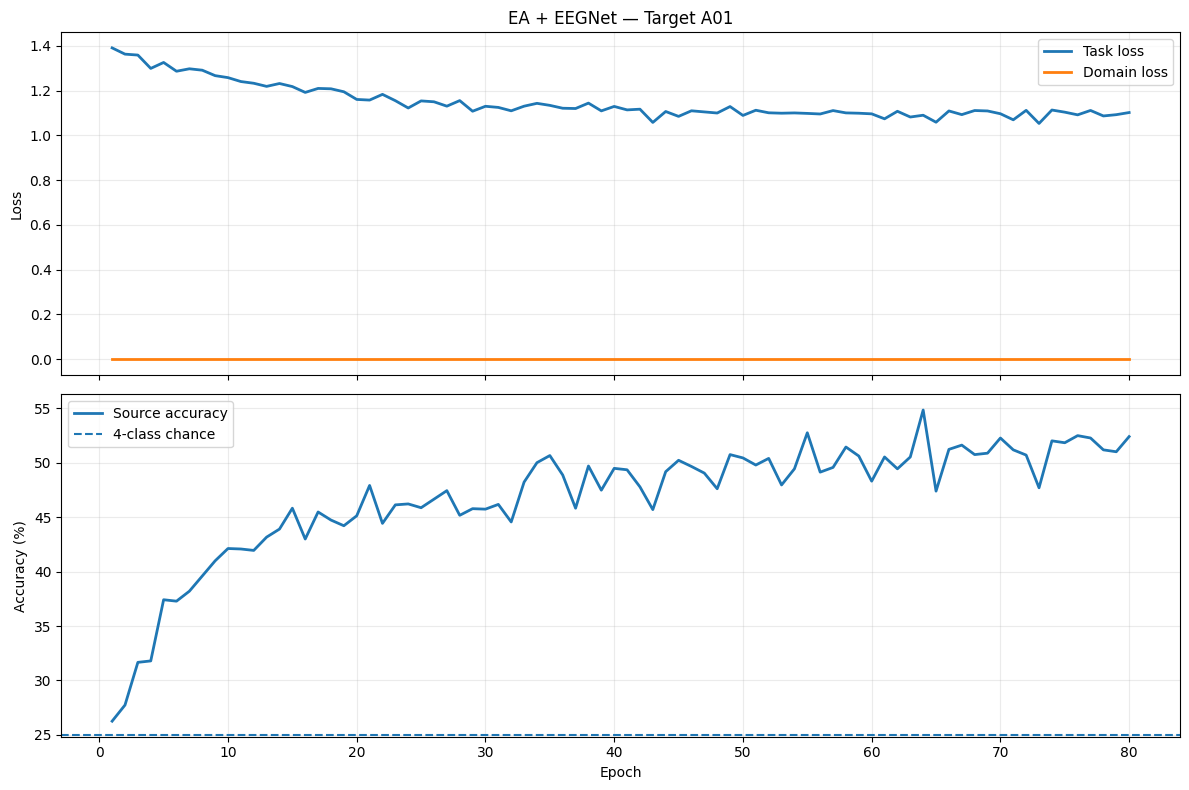

In [23]:

# CELL 22 — BASELINE HISTORY PLOT

def plot_training_history(
    history: pd.DataFrame,
    title: str,
):

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 8),
        sharex=True,
    )

    axes[0].plot(
        history["epoch"],
        history["loss_task"],
        label="Task loss",
        linewidth=2,
    )

    if (
        "loss_domain" in history.columns
        and history["loss_domain"].notna().any()
    ):
        axes[0].plot(
            history["epoch"],
            history["loss_domain"],
            label="Domain loss",
            linewidth=2,
        )

    axes[0].set_ylabel("Loss")
    axes[0].set_title(title)
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(
        history["epoch"],
        history["source_task_acc"] * 100,
        label="Source accuracy",
        linewidth=2,
    )

    axes[1].axhline(
        25.0,
        linestyle="--",
        linewidth=1.5,
        label="4-class chance",
    )

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_history(
    history_A01,
    "EA + EEGNet — Target A01",
)


In [24]:

# CELL 23 — FULL 9-FOLD LOSO RUN

def run_all_loso_folds():

    targets = list(
        CFG.SUBJECTS
    )

    if CFG.MAX_FOLDS is not None:
        targets = targets[
            :CFG.MAX_FOLDS
        ]

    all_results = []
    all_histories = []
    all_predictions = []

    mode_dir = (
        Path(CFG.OUTPUT_ROOT)
        / CFG.RUN_MODE
        / CFG.EA_TARGET_MODE
    )

    mode_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    for fold_idx, target_subject in enumerate(
        targets,
        start=1,
    ):

        print("\n")
        print("=" * 90)
        print(
            f"LOSO FOLD {fold_idx}/{len(targets)} "
            f"| TARGET = {target_subject}"
        )
        print("=" * 90)

        model, history, metrics, result = (
            run_one_fold(
                target_subject,
                verbose=True,
            )
        )

        all_results.append(
            result
        )

        history = history.copy()

        history[
            "target_subject"
        ] = target_subject

        all_histories.append(
            history
        )

        pred_df = pd.DataFrame({
            "target_subject": target_subject,
            "y_true": metrics["y_true"],
            "y_pred": metrics["y_pred"],
        })

        all_predictions.append(
            pred_df
        )

        fold_dir = (
            mode_dir
            / target_subject
        )

        fold_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        torch.save(
            model.state_dict(),
            fold_dir / "best_model.pt",
        )

        history.to_csv(
            fold_dir / "history.csv",
            index=False,
        )

        pred_df.to_csv(
            fold_dir / "predictions.csv",
            index=False,
        )

        np.save(
            fold_dir / "confusion_matrix.npy",
            metrics["confusion_matrix"],
        )

        print(
            f"{target_subject}: "
            f"Accuracy="
            f"{result['accuracy']*100:.2f}% | "
            f"Balanced="
            f"{result['balanced_accuracy']*100:.2f}% | "
            f"Macro-F1="
            f"{result['macro_f1']*100:.2f}%"
        )

    results_df = pd.DataFrame(
        all_results
    )

    histories_df = pd.concat(
        all_histories,
        ignore_index=True,
    )

    predictions_df = pd.concat(
        all_predictions,
        ignore_index=True,
    )

    results_df.to_csv(
        mode_dir / "loso_results.csv",
        index=False,
    )

    histories_df.to_csv(
        mode_dir / "all_histories.csv",
        index=False,
    )

    predictions_df.to_csv(
        mode_dir / "all_predictions.csv",
        index=False,
    )

    return (
        results_df,
        histories_df,
        predictions_df,
    )


In [ ]:

# CELL 24 — RUN THE FULL 9-FOLD EXPERIMENT

# AFTER the A01 test looks reasonable, change:
#
# CFG.MAX_FOLDS = None
#
# and then run this cell.

CFG.MAX_FOLDS = None

results_df, histories_df, predictions_df = (
    run_all_loso_folds()
)

display(results_df)




LOSO FOLD 1/9 | TARGET = A01

Target: A01
Sources: ['A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Source shape: (2296, 22, 1000)
Target shape: (287, 22, 1000)
EA target mode: transductive
[A01] Epoch 001/80 | Loss=1.3397 | SourceAcc=0.2282 | LR=0.0009996
[A01] Epoch 005/80 | Loss=1.2905 | SourceAcc=0.3415 | LR=0.0009905
[A01] Epoch 010/80 | Loss=1.2620 | SourceAcc=0.3802 | LR=0.0009623
[A01] Epoch 015/80 | Loss=1.2360 | SourceAcc=0.4238 | LR=0.0009166
[A01] Epoch 020/80 | Loss=1.1517 | SourceAcc=0.4399 | LR=0.0008550
[A01] Epoch 025/80 | Loss=1.1284 | SourceAcc=0.4508 | LR=0.0007800
[A01] Epoch 030/80 | Loss=1.1523 | SourceAcc=0.4869 | LR=0.0006944
[A01] Epoch 035/80 | Loss=1.1001 | SourceAcc=0.4747 | LR=0.0006016
[A01] Epoch 040/80 | Loss=1.0998 | SourceAcc=0.5096 | LR=0.0005050
[A01] Epoch 045/80 | Loss=1.1019 | SourceAcc=0.5009 | LR=0.0004084
[A01] Epoch 050/80 | Loss=1.0786 | SourceAcc=0.5004 | LR=0.0003156


In [ ]:

# CELL 25 — LOSO SUMMARY

def summarize_results(
    results_df: pd.DataFrame,
):

    rows = []

    for metric in [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ]:

        rows.append({
            "metric": metric,
            "mean": results_df[metric].mean(),
            "std": results_df[metric].std(
                ddof=1
            ),
            "min": results_df[metric].min(),
            "max": results_df[metric].max(),
        })

    summary = pd.DataFrame(
        rows
    )

    print(
        f"Accuracy: "
        f"{results_df['accuracy'].mean()*100:.2f} "
        f"± "
        f"{results_df['accuracy'].std(ddof=1)*100:.2f}%"
    )

    print(
        f"Balanced accuracy: "
        f"{results_df['balanced_accuracy'].mean()*100:.2f} "
        f"± "
        f"{results_df['balanced_accuracy'].std(ddof=1)*100:.2f}%"
    )

    print(
        f"Macro F1: "
        f"{results_df['macro_f1'].mean()*100:.2f} "
        f"± "
        f"{results_df['macro_f1'].std(ddof=1)*100:.2f}%"
    )

    display(summary)

    return summary


summary_df = summarize_results(
    results_df
)


In [ ]:

# CELL 26 — PER-SUBJECT CONFUSION MATRICES

def plot_loso_confusions(
    predictions_df,
):

    subjects = list(
        predictions_df[
            "target_subject"
        ].unique()
    )

    n = len(subjects)

    cols = 3
    rows = int(
        math.ceil(
            n / cols
        )
    )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(14, 4 * rows),
    )

    axes = np.atleast_1d(
        axes
    ).reshape(
        rows,
        cols,
    )

    for ax, sid in zip(
        axes.flat,
        subjects,
    ):

        data = predictions_df[
            predictions_df[
                "target_subject"
            ]
            == sid
        ]

        cm = confusion_matrix(
            data["y_true"],
            data["y_pred"],
            labels=[
                0,
                1,
                2,
                3,
            ],
        )

        im = ax.imshow(
            cm,
            interpolation="nearest",
        )

        ax.set_title(
            f"Target {sid}"
        )

        ax.set_xticks(
            range(4)
        )
        ax.set_yticks(
            range(4)
        )

        ax.set_xticklabels(
            CLASS_NAMES,
            rotation=35,
            ha="right",
        )

        ax.set_yticklabels(
            CLASS_NAMES
        )

        for i in range(4):
            for j in range(4):
                ax.text(
                    j,
                    i,
                    str(cm[i, j]),
                    ha="center",
                    va="center",
                )

        ax.set_xlabel(
            "Predicted"
        )

        ax.set_ylabel(
            "True"
        )

    for ax in axes.flat[
        len(subjects):
    ]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_loso_confusions(
    predictions_df
)



## 8. Recommended DANN run

Once the `baseline_ea` experiment is working, switch:

```python
CFG.RUN_MODE = "dann_binary"
CFG.EA_TARGET_MODE = "transductive"
CFG.LAMBDA_MAX = 0.30
CFG.MAX_FOLDS = 1
```

and run the A01 DANN cell below.

The binary discriminator sees balanced batches:

- source domain = `0`
- target domain = `1`

Unlike the previous notebook, the adversarial branch does **not** try to remove all 9-way subject identity at once.

A useful diagnostic is:

- task/source accuracy should rise above chance;
- domain accuracy should move toward ~50% as features become more domain-invariant;
- domain loss should approach the binary random-prediction cross-entropy rather than dominating the total loss.

Do not compare DANN results against the baseline until the preprocessing protocol is kept identical.


In [ ]:

# CELL 27 — A01 BINARY DANN TEST

CFG.RUN_MODE = "dann_binary"
CFG.EA_TARGET_MODE = "transductive"
CFG.LAMBDA_MAX = 0.30
CFG.MAX_FOLDS = 1
CFG.EPOCHS = 80

model_dann_A01, history_dann_A01, metrics_dann_A01, result_dann_A01 = (
    run_one_fold(
        target_subject="A01",
        verbose=True,
    )
)

print("\n" + "=" * 80)
print("A01 BINARY DANN RESULT")
print("=" * 80)

print(
    json.dumps(
        result_dann_A01,
        indent=2,
    )
)

plot_training_history(
    history_dann_A01,
    "Binary DANN + EA + EEGNet — Target A01",
)



## 9. Strict inductive experiment

For a completely target-inaccessible LOSO protocol:

```python
CFG.EA_TARGET_MODE = "identity"
```

and use:

```python
CFG.RUN_MODE = "baseline_ea"
```

for a strict source-only baseline, or:

```python
CFG.RUN_MODE = "dann_binary"
CFG.EA_TARGET_MODE = "identity"
```

for a stricter binary DANN experiment.

The difference between `transductive` and `identity` is important and should be reported explicitly in any paper.



## 10. Recommended experiment sequence

### Experiment A — Raw EEGNet

```python
CFG.RUN_MODE = "baseline_raw"
CFG.EA_TARGET_MODE = "identity"
```

### Experiment B — EA + EEGNet

```python
CFG.RUN_MODE = "baseline_ea"
CFG.EA_TARGET_MODE = "transductive"
```

### Experiment C — EA + binary DANN

```python
CFG.RUN_MODE = "dann_binary"
CFG.EA_TARGET_MODE = "transductive"
CFG.LAMBDA_MAX = 0.30
```

### Experiment D — Strict inductive binary DANN

```python
CFG.RUN_MODE = "dann_binary"
CFG.EA_TARGET_MODE = "identity"
CFG.LAMBDA_MAX = 0.30
```

Use the same LOSO folds, preprocessing, seed, EEGNet parameters, and optimization settings when comparing these conditions.


In [29]:

# CELL 28 — QUICK COMPARISON TABLE TEMPLATE
#
# Run each experiment separately and copy the resulting
# results_df into this list to build a common summary.

def results_summary_row(
    results_df,
    label,
):

    return {
        "experiment": label,
        "accuracy_mean": results_df[
            "accuracy"
        ].mean(),
        "accuracy_std": results_df[
            "accuracy"
        ].std(ddof=1),
        "balanced_accuracy_mean": results_df[
            "balanced_accuracy"
        ].mean(),
        "balanced_accuracy_std": results_df[
            "balanced_accuracy"
        ].std(ddof=1),
        "macro_f1_mean": results_df[
            "macro_f1"
        ].mean(),
        "macro_f1_std": results_df[
            "macro_f1"
        ].std(ddof=1),
    }

# Example after multiple experiments:
#
# comparison = pd.DataFrame([
#     results_summary_row(raw_results, "Raw EEGNet"),
#     results_summary_row(ea_results, "EA + EEGNet"),
#     results_summary_row(dann_results, "EA + Binary DANN"),
# ])
#
# display(comparison)
